In [3]:
import numpy as np
import matplotlib.pyplot as plt
from define_data_and_variables import get_data, get_hmc_config
import arviz as az
import glob, re
import os

In [2]:

print(os.path.exists("../../../output/tica/"))

True


In [7]:
data = get_data()
config, config_str = get_hmc_config()
colors = plt.cm.viridis(np.linspace(0, 1, config["nch"]))

In [4]:
eigenvalues = np.load(f"../../../output/tica/eigs_{config_str}.npy")
print((eigenvalues[0, :, :]))
directions = np.load(f"../../../output/tica/eig_vecs_{config_str}.npy")
taus = np.load(f"../../../output/tica/taus_{config_str}.npy")

[[0.99923098 0.99798914 0.99524249 0.98093084 0.92758109 0.88911847
  0.74392336 0.5089103  0.2668084  0.14508207]
 [0.99918938 0.99784915 0.9948494  0.97993503 0.91341922 0.87803459
  0.71617897 0.46452545 0.20612102 0.09732794]
 [0.99916841 0.99777699 0.99465618 0.97974485 0.905925   0.8738274
  0.70423945 0.44486724 0.18346631 0.07522677]
 [0.99912991 0.9977096  0.99444553 0.97935357 0.89906128 0.86876881
  0.69101245 0.43546075 0.17189205 0.05801786]
 [0.99908535 0.99760679 0.99415798 0.97876241 0.89360574 0.86187998
  0.68091479 0.41883273 0.16249793 0.04073698]
 [0.99901497 0.99751378 0.99378295 0.97813646 0.88912699 0.85558583
  0.67839734 0.40708297 0.14863391 0.03281707]
 [0.99898575 0.99744885 0.9935981  0.97741588 0.88706226 0.85043159
  0.67759443 0.40092099 0.14726623 0.02801494]
 [0.9989634  0.99737763 0.99348403 0.9771646  0.88500454 0.84692993
  0.67647168 0.39491903 0.1381236  0.03085276]
 [0.99895948 0.99730878 0.99337849 0.9768462  0.88391271 0.84321213
  0.67532219 

In [5]:
samples = np.load("../../../output/tica/samples_N50_H100_dc2.00_dt0.00_ndt10_nHMC10_ns10000_nch4_a1.50_b0.21_cutoff10.npy")

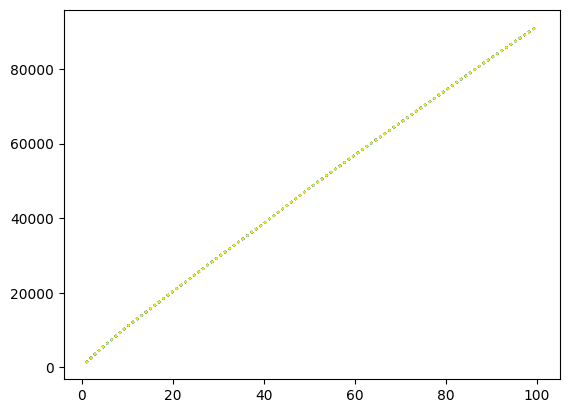

In [5]:
# for eig_index in range(config["N"]):
for chain_idx in range(config["nch"]):
    plt.plot(taus, -taus / np.log(eigenvalues[chain_idx, :, 0]), color = colors[chain_idx], linestyle = 'dotted')


In [6]:
print(energy_values)

[[ -5.36098359  -4.97351806   5.66877514 ...  31.34516965  29.70963829
   31.24502587]
 [ 26.19138619   4.25804502  -3.07277611 ...  28.92845911  31.45611164
   33.59938492]
 [ 58.75686352  61.54662568  57.5660371  ...  97.67750585  96.97024785
  100.31696881]
 [ 29.98517515  15.55796978   0.16538799 ...  31.00370973  28.59821106
   31.66265646]]


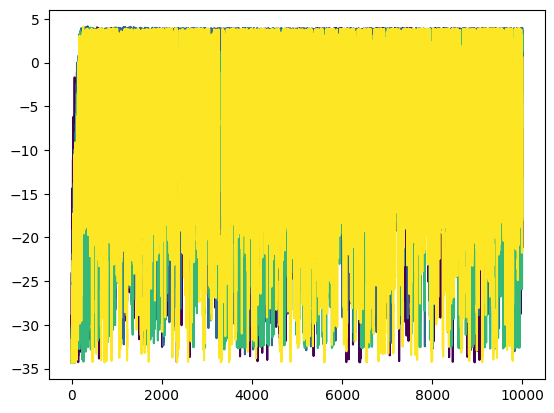

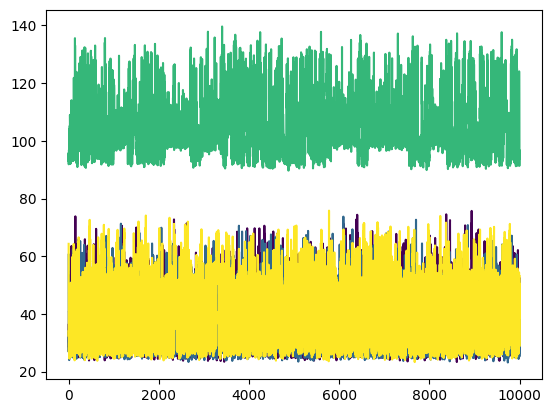

In [7]:
plt.figure()
for i in range(config["nch"]):
    plt.plot(bias_values[i,:], color = colors[i])
plt.show()

plt.figure()
for i in range(config["nch"]):
    plt.plot(energy_values[i,:] - bias_values[i,:], color = colors[i])
plt.show()


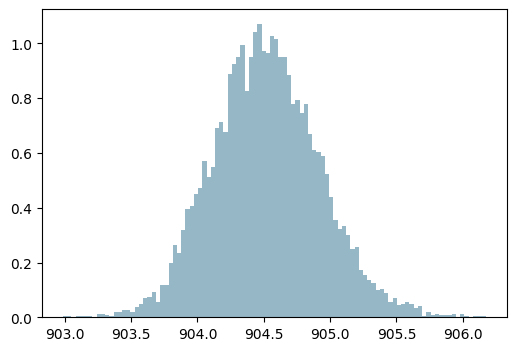

IndexError: index 4 is out of bounds for axis 0 with size 4

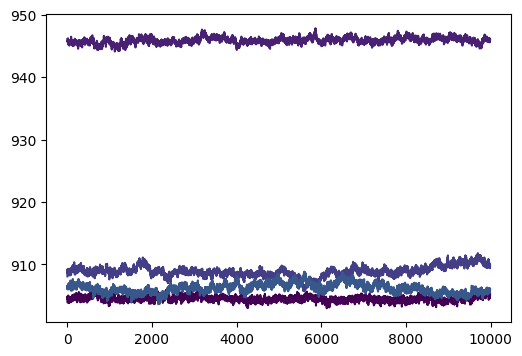

In [ ]:
CV_values = data["theta"] - config["dc"] * np.sum(samples[:, :, :config["pidx"]], axis = 2)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.plot(CV_values[i, :], color = colors[i], label = f"chain {i}")
plt.show()

In [9]:
resampled_samples = resampled_samples[:,::1000,:]

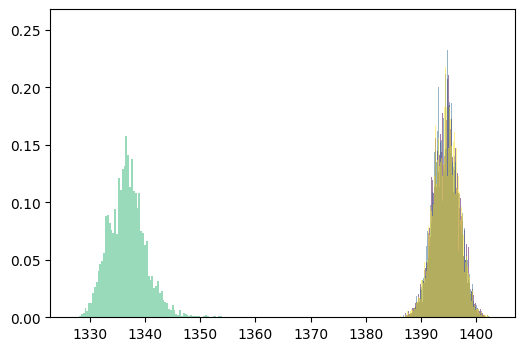

In [9]:
CV_values = data["theta"] - config["dc"] * np.sum(resampled_samples[:, :, :config["pidx"]], axis = 2)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
plt.show()

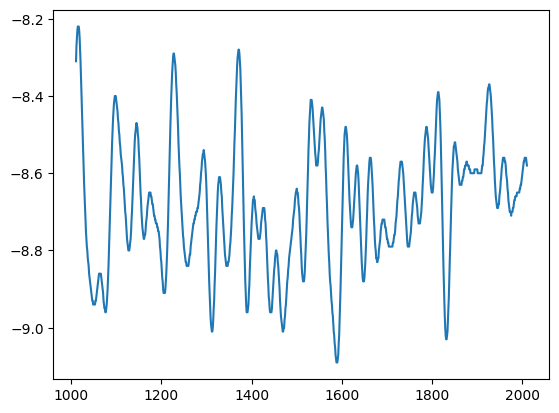

In [6]:
indices = []
for i in range(len(data["d18O_depths"])):
    index = get_index(config["N"], config["cs"], data["d18O_depths"], i)
    indices.append(index)

plt.figure()
plt.plot(data["d18O_reference_times"], data["d18O_reference"])
# for i in range(config["nch"]):
#     variables = resampled_samples[i,:,:]
#     for j in range(len(variables)):
#         d18O_ages = expected_ages(config["N"], config["dc"], config["cs"], data["theta"], len(data["d18O_depths"]), data["d18O_depths"], variables[j,:], indices)
#         plt.plot(d18O_ages, data["d18O"], '*', color = colors[i])

# plt.plot(data["true_ages_D18O"], data["d18O"], '*', color = "k")
plt.show()

In [11]:
# Print R_hat and N_eff using arviz
idata = az.convert_to_inference_data(resampled_samples)
summary = az.summary(idata, round_to=2)
print(summary)

       mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x[0]  10.08   1.07    8.07    12.02       0.01     0.00  38637.93  39494.17   
x[1]  11.21   1.85    7.68    14.58       0.01     0.01  39210.99  39128.29   
x[2]   8.14   2.55    3.67    13.47       0.08     0.01   1389.79  35454.51   
x[3]  10.39   2.62    6.01    15.75       0.02     0.05   1009.39  33663.69   
x[4]  30.13  12.66   19.75    53.22       6.24     3.63      7.06     25.08   
x[5]  10.93   4.83    1.25    16.83       2.25     1.22      7.07     25.11   
x[6]  13.49   2.18    9.44    17.63       0.01     0.09  35087.35  19941.23   
x[7]  13.82   2.61    9.27    18.73       0.63     0.01     17.02     86.69   
x[8]  11.41   6.31    0.02    17.92       3.02     1.59      7.06     24.84   
x[9]   5.04   3.48    0.15    11.46       0.68     0.05     24.21    222.15   

      r_hat  
x[0]   1.00  
x[1]   1.00  
x[2]   1.01  
x[3]   1.01  
x[4]   1.53  
x[5]   1.52  
x[6]   1.02  
x[7]   1.15  
x[8]